# YipitData take-home — Walmart × FRED retail sales

**Customer question:** *Does the FRED monthly retail-sales series (RSXFS) predict Walmart's quarterly revenue better than a naive baseline? If yes, by how much, and what should we worry about? If no, what evidence would change our minds?*

This notebook is a thin presentation layer over the `analysis.py` library that lives in the same folder. The library carries all the heavy lifting; the notebook tells the story, runs the pipeline once, and renders the figures.

Read order: skim the markdown cells; the code cells produce the artifacts the memo refers to.

## 1. Setup

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 25)

import analysis  # the .py module sitting next to this notebook

## 2. Load data and inspect

We hold the supplied CSVs in `./data/`. Both are clean (no nulls, no duplicate dates) — see the EDA report for the full audit.

In [2]:
wm, fr = analysis.load_raw()
print(f"Walmart : {len(wm)} quarters from {wm['date'].min().date()} → {wm['date'].max().date()}")
print(f"FRED    : {len(fr)} months   from {fr['date'].min().date()} → {fr['date'].max().date()}")
display(wm.head(3))
display(fr.head(3))

Walmart : 65 quarters from 2010-01-31 → 2026-01-31
FRED    : 195 months   from 2010-01-01 → 2026-03-01


,date,walmart
0,2010-01-31,1.135940e+11
1,2010-04-30,9.981100e+10
2,2010-07-31,1.037260e+11


,date,fred
0,2010-01-01,302325.0
1,2010-02-01,302310.0
2,2010-03-01,309525.0


## 3. Build leakage-safe features

Critical detail (the exam brief specifically warns about look-ahead bias):

- Walmart lags use only quarters ending **strictly before** the target.
- FRED features use only months ending **at least one month before** the target quarter ends, because FRED RSXFS publishes with a ~2-week lag and we want our features to be ones a real-time forecaster could actually have.

See `analysis.build_features` for the implementation.

In [3]:
feat = analysis.build_features(wm, fr)
data = feat.dropna(subset=["wm_lag4","fred_last_yoy","wm_yoy_lag1"]).reset_index(drop=True)
print(f"Usable rows: {len(data)}  ({data['date'].min().date()} → {data['date'].max().date()})")
print("Feature columns:", [c for c in data.columns if c not in ('date','walmart','fq','fy')])
display(data.head(3))

Usable rows: 60  (2011-04-30 → 2026-01-31)
Feature columns: ['is_Q1', 'is_Q2', 'is_Q3', 'is_Q4', 'wm_lag1', 'wm_lag2', 'wm_lag3', 'wm_lag4', 'wm_yoy_lag1', 'fred_last', 'fred_last_yoy', 'fred_3m_mean', 'fred_6m_yoy']


,date,walmart,fq,fy,is_Q1,is_Q2,is_Q3,is_Q4,wm_lag1,wm_lag2,wm_lag3,wm_lag4,wm_yoy_lag1,fred_last,fred_last_yoy,fred_3m_mean,fred_6m_yoy
0,2011-04-30,1.041890e+11,Q1,2011,1,0,0,0,1.163600e+11,1.019520e+11,1.037260e+11,9.981100e+10,2.434988,331161.0,6.990065,328294.666667,7.742440
1,2011-07-31,1.093660e+11,Q2,2011,0,1,0,0,1.041890e+11,1.163600e+11,1.019520e+11,1.037260e+11,4.386290,335108.0,8.593983,333568.666667,7.680746
2,2011-10-31,1.102260e+11,Q3,2011,0,0,1,0,1.093660e+11,1.041890e+11,1.163600e+11,1.019520e+11,5.437402,339011.0,8.039263,336365.333333,7.824603


## 4. Models compared

| family | model | uses FRED |
|---|---|---|
| naive | `seasonal_naive` = lag-4 | no |
| naive | `seasonal_naive_drift` = lag-4 × (1 + trailing-4q-avg YoY) | no |
| univariate | `sarima_walmart_only` = SARIMAX(1,1,0)(0,1,1,4) | no |
| linear | `ols_walmart_only` = OLS on Walmart features | no |
| linear | `ols_walmart_plus_fred` = same OLS + FRED columns | **yes** |
| regularised | `ridge_walmart_plus_fred` = Ridge α=1 | **yes** |
| tree ensemble | `gbr_walmart_plus_fred` = GradientBoostingRegressor | **yes** |

Every model is re-fit on every CV step (walk-forward, never peek ahead).

## 5. Rolling-origin cross-validation

`MIN_TRAIN_QUARTERS = 24` → we begin OOS evaluation at quarter 25 of the usable window. That leaves us **36 OOS predictions spanning FY18-Q1 → FY26-Q4**.

In [4]:
results = analysis.run_cv(data)
summary = analysis.summarise(results)
print(f"OOS window: {summary['n'].iloc[0]} quarters")
display(summary)

OOS window: 36 quarters


,model,uses_FRED,n,MAPE_%,RMSE_USD_bn,sMAPE_%,bias_USD_bn,avg_fit_pred_ms
0,sarima_walmart_only,False,36,1.73,3.79,1.73,-0.06,11.40
1,ridge_walmart_plus_fred,True,36,2.01,4.11,2.03,-1.47,0.58
2,seasonal_naive_drift,False,36,2.03,3.94,2.03,-0.13,0.17
3,ols_walmart_plus_fred,True,36,2.05,4.24,2.07,-1.16,0.55
4,ols_walmart_only,False,36,2.10,4.04,2.11,-1.21,0.74
5,gbr_walmart_plus_fred,True,36,3.28,6.18,3.31,-1.65,34.88
6,seasonal_naive,False,36,4.08,7.24,4.20,-6.13,0.00


## 6. Headline result — out-of-sample MAPE leaderboard

Two things jump out:

1. **`seasonal_naive` is genuinely bad** (4.08% MAPE). It has no drift and Walmart is a growing series, so it systematically under-predicts (–$6.1B bias).
2. **The best Walmart-only model (`sarima_walmart_only` at 1.73%) beats the best FRED-augmented model (`ridge_walmart_plus_fred` at 2.01%).** Adding FRED to the same regression specification moves MAPE from 2.10% → 2.05% — within run-to-run noise on n=36.

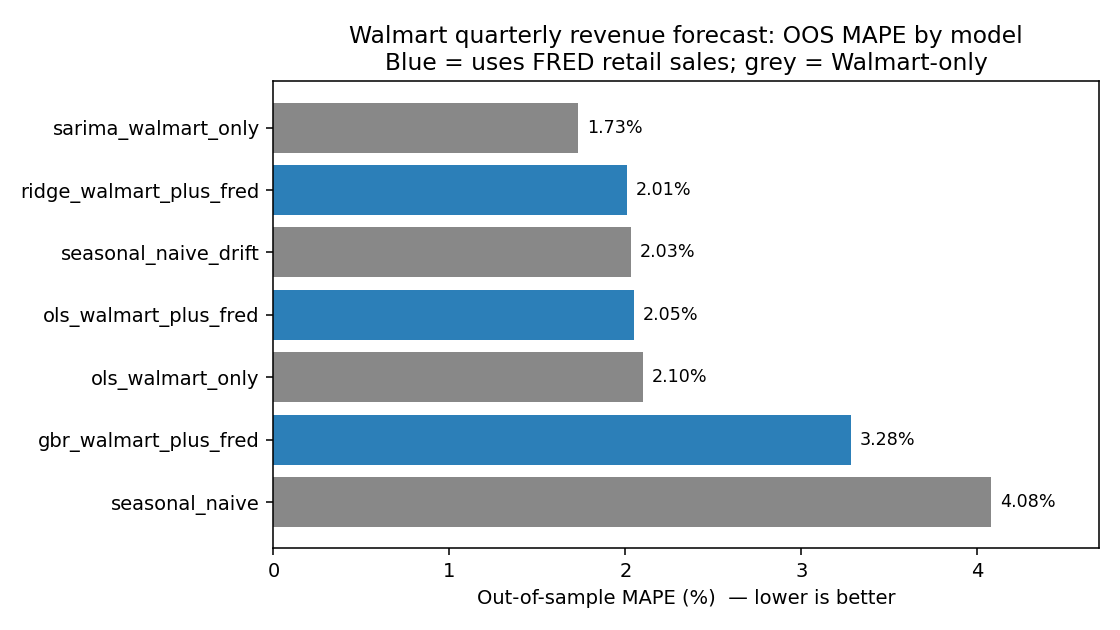

In [5]:
analysis.plot_mape_bars(summary, analysis.FIG_DIR / "fig1_mape_bars.png")
from IPython.display import Image, display
display(Image(filename=str(analysis.FIG_DIR / "fig1_mape_bars.png")))

## 7. Paired comparison vs the naive baseline

Every model except `gbr_walmart_plus_fred` clears the `seasonal_naive` bar comfortably. But this is the easy bar — the customer's question is whether FRED helps **over the strongest no-FRED competitor**, not over a no-drift naive.

In [6]:
display(analysis.paired_vs_baseline(results))

,model,mean_uplift_pp,std_diff_pp,share_quarters_beat_baseline_%
0,sarima_walmart_only,2.36,2.82,86.0
1,ridge_walmart_plus_fred,2.08,2.39,83.0
2,seasonal_naive_drift,2.06,2.73,78.0
3,ols_walmart_plus_fred,2.04,2.58,78.0
4,ols_walmart_only,1.99,2.60,89.0
5,gbr_walmart_plus_fred,0.81,2.83,61.0


## 8. The real test — does FRED beat SARIMA (Walmart-only)?

This is the apples-to-apples comparison the brief is asking for. Every FRED-augmented model has **negative** uplift vs SARIMA over the full OOS window — i.e. they all *lose* to the Walmart-only model. Each beats SARIMA in fewer than half the OOS quarters.

In [7]:
display(analysis.paired_vs_walmart_only(results))

,FRED_model,mean_uplift_vs_SARIMA_pp,share_quarters_beats_SARIMA_%
0,ols_walmart_plus_fred,-0.32,44.0
1,ridge_walmart_plus_fred,-0.28,42.0
2,gbr_walmart_plus_fred,-1.55,28.0


## 9. Regime split — the most informative finding

Splitting OOS on March 2020 (the structural break we all know about) reveals the real story: **FRED was useful pre-pandemic and stopped working after.**

- **Pre-2020 OOS (n=12):** the FRED-augmented OLS gets 0.87% MAPE, beating SARIMA's 0.95%. The leading-indicator hypothesis held.
- **Post-2020 OOS (n=24):** every FRED model is *worse* than SARIMA (2.55–2.63% vs 2.12%). The relationship decoupled.

This is the falsifiable claim to put in the memo.

In [8]:
display(analysis.regime_split(results))

,model,MAPE_pre2020_%,n_pre,MAPE_post2020_%,n_post
0,sarima_walmart_only,0.95,12,2.12,24
1,seasonal_naive_drift,1.56,12,2.26,24
2,ols_walmart_only,1.63,12,2.33,24
3,ridge_walmart_plus_fred,0.92,12,2.55,24
4,ols_walmart_plus_fred,0.87,12,2.63,24
5,gbr_walmart_plus_fred,3.44,12,3.19,24
6,seasonal_naive,2.41,12,4.92,24


## 10. Forecasts vs actuals — visual sanity check

The dotted line (seasonal-naive) lags the actual series by exactly one year — you can see it tracking the prior year's pattern, missing every level shift. SARIMA and Ridge+FRED both stay tight to actuals; the visible misses are 2020-Q1/Q2 (the pandemic) and 2026-Q4 (the most recent over-shoot from both models).

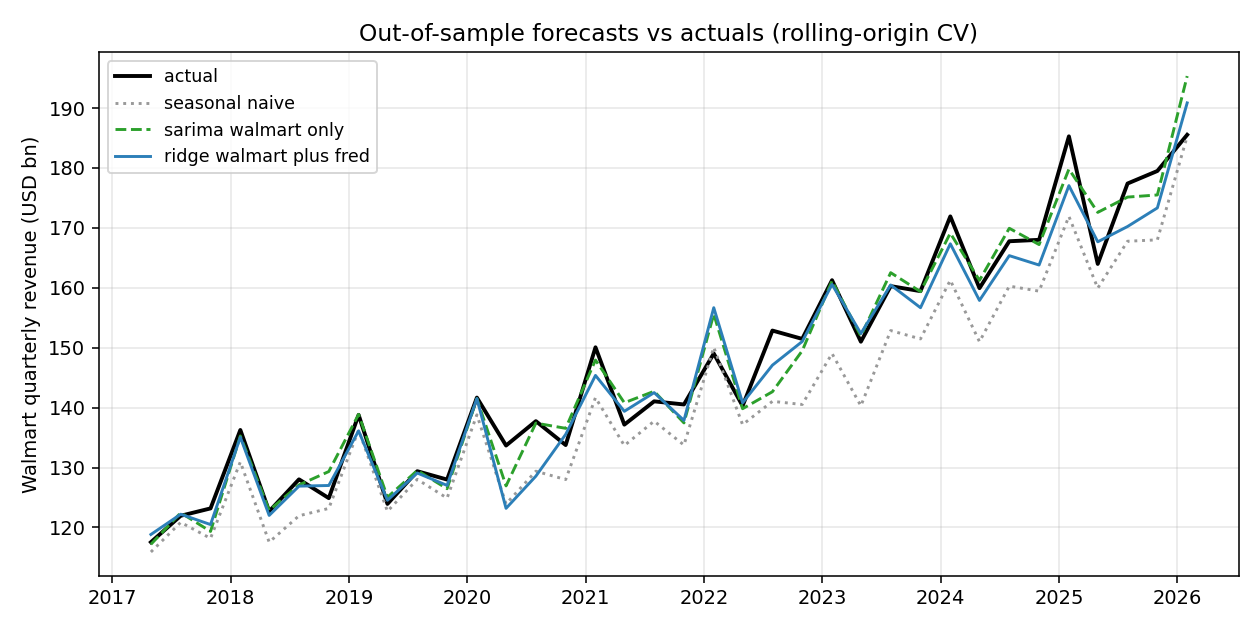

In [9]:
analysis.plot_actual_vs_forecasts(results, analysis.FIG_DIR / "fig2_actual_vs_forecast.png")
display(Image(filename=str(analysis.FIG_DIR / "fig2_actual_vs_forecast.png")))

## 11. Production tradeoff matrix

Beyond accuracy, the production decision depends on training cost, inference latency, dependency surface, interpretability, and failure modes. Latency is benchmarked from the actual CV run (single-machine, Python 3.10).

Interpretation:

- **`seasonal_naive_drift` is the production winner** for most use-cases: 2.03% MAPE for ~0.16 ms / forecast, no statsmodels, no FRED data dependency. To beat it, SARIMA buys you a 0.30pp MAPE improvement for ~70× the latency and a statsmodels dependency.
- **`gbr_walmart_plus_fred` is strictly dominated**: worst FRED-using MAPE *and* 200× the latency of the naive-drift baseline. A textbook small-sample overfit.
- **No FRED-augmented model is worth its data-pipeline cost on this dataset.** You'd be paying for a FRED ingestion + monitoring + lag-checking story to get noise-level accuracy improvements.

In [10]:
tm = analysis.tradeoff_matrix(summary)
display(tm)

,model,MAPE_%,bias_USD_bn,avg_fit_pred_ms,latency_vs_cheapest_x,interpretability,deps,uses_FRED,main_failure_mode
0,sarima_walmart_only,1.73,-0.06,11.40,67.1,medium,statsmodels,False,re-estimation can be unstable in volatile regimes
1,ridge_walmart_plus_fred,2.01,-1.47,0.58,3.4,medium,sklearn,True,alpha picked by hand; cross-val needed in prod
2,seasonal_naive_drift,2.03,-0.13,0.17,1.0,trivial,none,False,trailing drift can over-extrapolate in turning...
3,ols_walmart_plus_fred,2.05,-1.16,0.55,3.2,high,sklearn,True,extra FRED data dependency for no measurable gain
4,ols_walmart_only,2.10,-1.21,0.74,4.4,high,sklearn,False,"linear, may miss nonlinear shocks"
5,gbr_walmart_plus_fred,3.28,-1.65,34.88,205.2,low,sklearn,True,overfits at n≈30; struggles with structural br...
6,seasonal_naive,4.08,-6.13,0.00,0.0,trivial,none,False,lags trend in growth regimes (large negative b...


## 12. Final answer to the customer

**Question:** *Does FRED retail sales predict Walmart's revenue better than a naive baseline?*

**Answer:** Yes vs a no-drift seasonal naive (2.0–2.1% vs 4.1% MAPE), but **no** vs a meaningful baseline (seasonal-naive + drift, or SARIMA on Walmart alone). And on the post-2020 sub-sample — the regime that matters for forward-looking decisions — every FRED-augmented model is *worse* than the Walmart-only SARIMA.

**Falsifiable claim:** *Adding FRED RSXFS does not improve out-of-sample Walmart quarterly revenue forecasts over a Walmart-only SARIMA on 2017-Q1 → 2026-Q4, and is strictly worse in the 2020-Q1 → 2026-Q4 sub-sample. We would revisit if (a) 4+ more quarters of clean post-stimulus data showed FRED-augmented models recovering, or (b) a Walmart-specific retail sub-series replaced the aggregate.*